In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#wireless commm implementation (riya rajput, kunal sati)

#implentation is not copied from the original paper - we had our own pipeline
#we used resnet18 for image processing instead of a custom CNN
#used a simple path loss function with offset correction and tested out our model against it
#this test demonstrates that ML can be employed for effective margin prediction for path loss models to determine actual received power

#model was able to match efficiently the working of path loss (similar results -> ~9.5 between predicted and actual rsrp)

#results for freq 2.630 -> rsme of 4.7 for residual margin prediction
#results for freq 0.811 -> rsme of 6.2 for residual margin prediction

#we were able to match the resuls with the path loss model used (power = 43 fixed)
#mean offset used

#end of file also contains some experimentation part (to be ignored)
#hyperparam alpha = 0.009 determined to scale the predicted residual

#not to be taken as an improved version - but a demonstration of the principle used in the paper (much can be done - we had limited system resources)

In [3]:
df = pd.read_csv("/content/drive/MyDrive/WIRELESSCOM/wcomdataset.csv", index_col = 0)

In [ ]:
#df1 = pd.read_csv("/content/drive/MyDrive/WIRELESSCOM/wirelesscode/raw_data/feature_matrix.csv")
#df2 = pd.read_csv("/content/drive/MyDrive/WIRELESSCOM/wirelesscode/raw_data/output_matrix.csv")

#df = pd.concat([df1, df2['RSRP']], axis=1)

In [4]:
#df['index'] = df['Unnamed: 0']

In [ ]:
#df = df.drop(['Unnamed: 0', 'PCI'], axis=1)

In [5]:
df

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP
0,53735,12.513810,55.781135,15.88,0.721475,-0.003535,-0.009671,0,0,1,-124.83
1,56186,12.528917,55.795474,0.87,1.248863,0.010804,0.005436,0,0,1,-136.53
2,52546,12.527072,55.795562,13.57,1.232131,0.010892,0.003591,0,0,1,-133.63
3,54201,12.529027,55.792470,34.42,0.934332,0.007800,0.005546,0,0,1,-135.14
4,56261,12.528338,55.790267,54.89,0.692687,0.005597,0.004857,0,0,1,-123.17
...,...,...,...,...,...,...,...,...,...,...,...
795,19398,12.521089,55.785623,9.73,0.183340,0.000953,-0.002392,0,1,0,-68.78
796,18225,12.516981,55.785333,16.35,0.413170,0.000663,-0.006500,0,1,0,-64.80
797,19996,12.521737,55.785450,21.74,0.139360,0.000780,-0.001744,0,1,0,-68.96
798,173,12.520005,55.779501,17.57,0.614704,-0.005169,-0.003476,1,0,0,-64.23


In [6]:
from scipy.constants import speed_of_light
import numpy as np
import matplotlib.pyplot as plt

def uma_los(d3d, d2d, dbp, fc, h_b, h_t):
    # 38.901 UMa LOS
    PL1 = 28+22*np.log10(d3d)+20*np.log10(fc)
    PL2 = 28+40*np.log10(d3d)+20*np.log10(fc) - 9*np.log10(dbp**2+(h_b - h_t)**2)
    PL = np.zeros((d3d.shape))
    PL = PL2 # Default pathloss
    PL[(np.greater_equal(d2d,10) & np.less_equal(d2d,dbp))] = PL1[(np.greater_equal(d2d,10) & np.less_equal(d2d,dbp))] # Overwrite if distance is greater than 10 meters or smaller than dbp

    return PL

def uma_nlos(d3d, d2d, dbp, fc, h_b, h_t):
    # 38901 UMa NLOS
    PL_nlos = 13.54+39.08*np.log10(d3d)+20*np.log10(fc)-0.6*(h_t-1.5)
    PL = np.zeros((d3d.shape))
    PL = np.maximum(uma_los(d3d, d2d, dbp, fc, h_b, h_t), PL_nlos)

    return PL

def pathloss_38901(distance, frequency, h_bs=30, h_ut=1.5):
    """
        Simple path loss model for computing RSRP based on distance.

        fc: frequency in GHz
        h_b: height of basestation
        h_t: height of UT
    """
    # Constants
    fc = frequency
    h_b =  h_bs # 30 meters
    h_t =  h_ut # 1.5

    # 2D distance
    d2d = distance

    # 3D distance
    h_e = h_b - h_t # effective height
    d3d = np.sqrt(d2d**2+h_e**2)

    # Breakpoint distance
    dbp =  4*h_b*h_t*fc*10e8/speed_of_light

    loss = uma_nlos(d3d, d2d, dbp, fc, h_b, h_t)
    return loss

In [10]:
def pathloss_38901_diff(distance, frequency, h_bs=30, h_ut=1.5):

    fc = frequency  # GHz
    fc_hz = fc * 1e9

    h_b = h_bs
    h_t = h_ut

    d2d = np.maximum(distance, 10)  # enforce model validity

    h_e = h_b - h_t
    d3d = np.sqrt(d2d**2 + h_e**2)

    dbp = 4 * h_b * h_t * fc_hz / speed_of_light

    loss = uma_nlos(d3d, d2d, dbp, fc, h_b, h_t)
    return loss

In [7]:
#mapping
pci_to_freq = {
    64: 0.811,
    65: 0.811,
    302: 2.63
}

In [8]:
df['Distance'] = df['Distance']*1000

In [9]:
df

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP
0,53735,12.513810,55.781135,15.88,721.475240,-0.003535,-0.009671,0,0,1,-124.83
1,56186,12.528917,55.795474,0.87,1248.863114,0.010804,0.005436,0,0,1,-136.53
2,52546,12.527072,55.795562,13.57,1232.130780,0.010892,0.003591,0,0,1,-133.63
3,54201,12.529027,55.792470,34.42,934.332152,0.007800,0.005546,0,0,1,-135.14
4,56261,12.528338,55.790267,54.89,692.686683,0.005597,0.004857,0,0,1,-123.17
...,...,...,...,...,...,...,...,...,...,...,...
795,19398,12.521089,55.785623,9.73,183.340260,0.000953,-0.002392,0,1,0,-68.78
796,18225,12.516981,55.785333,16.35,413.169903,0.000663,-0.006500,0,1,0,-64.80
797,19996,12.521737,55.785450,21.74,139.359994,0.000780,-0.001744,0,1,0,-68.96
798,173,12.520005,55.779501,17.57,614.704436,-0.005169,-0.003476,1,0,0,-64.23


In [10]:
df['frequency'] = np.where(df['PCI_302'] == 1, 2.63, 0.811)

In [11]:
df

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP,frequency
0,53735,12.513810,55.781135,15.88,721.475240,-0.003535,-0.009671,0,0,1,-124.83,2.630
1,56186,12.528917,55.795474,0.87,1248.863114,0.010804,0.005436,0,0,1,-136.53,2.630
2,52546,12.527072,55.795562,13.57,1232.130780,0.010892,0.003591,0,0,1,-133.63,2.630
3,54201,12.529027,55.792470,34.42,934.332152,0.007800,0.005546,0,0,1,-135.14,2.630
4,56261,12.528338,55.790267,54.89,692.686683,0.005597,0.004857,0,0,1,-123.17,2.630
...,...,...,...,...,...,...,...,...,...,...,...,...
795,19398,12.521089,55.785623,9.73,183.340260,0.000953,-0.002392,0,1,0,-68.78,0.811
796,18225,12.516981,55.785333,16.35,413.169903,0.000663,-0.006500,0,1,0,-64.80,0.811
797,19996,12.521737,55.785450,21.74,139.359994,0.000780,-0.001744,0,1,0,-68.96,0.811
798,173,12.520005,55.779501,17.57,614.704436,-0.005169,-0.003476,1,0,0,-64.23,0.811


In [12]:
df['path_loss'] = pathloss_38901(
    df['Distance'].values,
    df['frequency'].values
)

In [13]:
#df['rsrp_est'] = 43 - df['path_loss'] - 10*np.log10(100)  #fixed power 43m N_b = 100 whatever it is
df['rsrp_est'] = 43 - df['path_loss'] #- 10*np.log10(12 * 100)

In [14]:
df

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP,frequency,path_loss,rsrp_est
0,53735,12.513810,55.781135,15.88,721.475240,-0.003535,-0.009671,0,0,1,-124.83,2.630,133.651640,-90.651640
1,56186,12.528917,55.795474,0.87,1248.863114,0.010804,0.005436,0,0,1,-136.53,2.630,142.955333,-99.955333
2,52546,12.527072,55.795562,13.57,1232.130780,0.010892,0.003591,0,0,1,-133.63,2.630,142.726522,-99.726522
3,54201,12.529027,55.792470,34.42,934.332152,0.007800,0.005546,0,0,1,-135.14,2.630,138.034198,-95.034198
4,56261,12.528338,55.790267,54.89,692.686683,0.005597,0.004857,0,0,1,-123.17,2.630,132.961648,-89.961648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,19398,12.521089,55.785623,9.73,183.340260,0.000953,-0.002392,0,1,0,-68.78,0.811,100.371156,-57.371156
796,18225,12.516981,55.785333,16.35,413.169903,0.000663,-0.006500,0,1,0,-64.80,0.811,113.999008,-70.999008
797,19996,12.521737,55.785450,21.74,139.359994,0.000780,-0.001744,0,1,0,-68.96,0.811,95.861027,-52.861027
798,173,12.520005,55.779501,17.57,614.704436,-0.005169,-0.003476,1,0,0,-64.23,0.811,120.719720,-77.719720


In [ ]:
#df['residual'] = df['RSRP'] - df['rsrp_est']

In [15]:
df_2630 = df[df['PCI_302'] == 1]
df_811 = df[df['PCI_302'] == 0]

In [16]:
#finding offset
offset_811 = np.mean(df_811['RSRP'] - df_811['rsrp_est'])
offset_2630 = np.mean(df_2630['RSRP'] - df_2630['rsrp_est'])


In [17]:
df_811['rsrp_est'] = df_811['rsrp_est'] + offset_811
df_2630['rsrp_est'] = df_2630['rsrp_est'] + offset_2630

/tmp/ipykernel_1683/1997309753.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_811['rsrp_est'] = df_811['rsrp_est'] + offset_811
/tmp/ipykernel_1683/1997309753.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2630['rsrp_est'] = df_2630['rsrp_est'] + offset_2630


In [18]:
df_811['residual'] = df_811['RSRP'] - df_811['rsrp_est']
df_2630['residual'] = df_2630['RSRP'] - df_2630['rsrp_est']

/tmp/ipykernel_1683/1404836704.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_811['residual'] = df_811['RSRP'] - df_811['rsrp_est']
/tmp/ipykernel_1683/1404836704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2630['residual'] = df_2630['RSRP'] - df_2630['rsrp_est']


In [19]:
df_811

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP,frequency,path_loss,rsrp_est,residual
168,11234,12.514031,55.783218,13.29,612.735901,-0.001452,-0.009450,1,0,0,-105.60,0.811,120.665398,-92.253117,-13.346883
175,32842,12.528941,55.792125,42.27,896.751619,0.007455,0.005460,0,1,0,-106.54,0.811,127.119413,-98.707132,-7.832868
190,11512,12.515973,55.780517,15.41,658.743832,-0.004153,-0.007508,1,0,0,-106.79,0.811,121.891730,-93.479449,-13.310551
191,11563,12.514840,55.781277,1.60,659.214127,-0.003393,-0.008641,1,0,0,-109.21,0.811,121.903820,-93.491539,-15.718461
193,33167,12.515523,55.780279,9.89,697.375678,-0.004391,-0.007958,0,1,0,-106.76,0.811,122.857261,-94.444980,-12.315020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,19398,12.521089,55.785623,9.73,183.340260,0.000953,-0.002392,0,1,0,-68.78,0.811,100.371156,-71.958875,3.178875
796,18225,12.516981,55.785333,16.35,413.169903,0.000663,-0.006500,0,1,0,-64.80,0.811,113.999008,-85.586727,20.786727
797,19996,12.521737,55.785450,21.74,139.359994,0.000780,-0.001744,0,1,0,-68.96,0.811,95.861027,-67.448746,-1.511254
798,173,12.520005,55.779501,17.57,614.704436,-0.005169,-0.003476,1,0,0,-64.23,0.811,120.719720,-92.307439,28.077439


In [20]:
df_2630

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP,frequency,path_loss,rsrp_est,residual
0,53735,12.513810,55.781135,15.88,721.475240,-0.003535,-0.009671,0,0,1,-124.83,2.63,133.651640,-119.567315,-5.262685
1,56186,12.528917,55.795474,0.87,1248.863114,0.010804,0.005436,0,0,1,-136.53,2.63,142.955333,-128.871008,-7.658992
2,52546,12.527072,55.795562,13.57,1232.130780,0.010892,0.003591,0,0,1,-133.63,2.63,142.726522,-128.642197,-4.987803
3,54201,12.529027,55.792470,34.42,934.332152,0.007800,0.005546,0,0,1,-135.14,2.63,138.034198,-123.949873,-11.190127
4,56261,12.528338,55.790267,54.89,692.686683,0.005597,0.004857,0,0,1,-123.17,2.63,132.961648,-118.877323,-4.292677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,36895,12.516793,55.784985,14.96,419.762590,0.000315,-0.006688,0,0,1,-77.25,2.63,124.485130,-110.400805,33.150805
690,34956,12.517049,55.785466,18.07,411.908927,0.000796,-0.006432,0,0,1,-75.99,2.63,124.166074,-110.081749,34.091749
691,34980,12.517103,55.785568,15.37,411.217507,0.000898,-0.006378,0,0,1,-75.32,2.63,124.137697,-110.053372,34.733372
700,35038,12.523469,55.784887,13.81,24.126305,0.000217,-0.000012,0,0,1,-77.90,2.63,83.380010,-69.295685,-8.604315


In [21]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_2630['RSRP'], df_2630['rsrp_est']))
print("RMSE (Actual vs Predicted) for Frequency 2630 :", rmse)

RMSE (Actual vs Predicted) for Frequency 2630 : 9.368306860253746


In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_811['RSRP'], df_811['rsrp_est']))
print("RMSE (Actual vs Predicted) for Frequency 811 :", rmse)

RMSE (Actual vs Predicted) for Frequency 811 : 9.484110447330059


In [23]:
df_811.shape

(469, 15)

In [24]:
df_2630.shape

(331, 15)

In [ ]:
#df_811.to_csv('/content/drive/MyDrive/WIRELESSCOM/df_811.csv')
#df_2630.to_csv('/content/drive/MyDrive/WIRELESSCOM/df_2630.csv')

In [ ]:
#HASHED - will be predicting for the residual

In [25]:
df_811.columns

Index(['index', 'Longitude', 'Latitude', 'Speed', 'Distance', 'Distance_x',
       'Distance_y', 'PCI_64', 'PCI_65', 'PCI_302', 'RSRP', 'frequency',
       'path_loss', 'rsrp_est', 'residual'],
      dtype='object')

In [98]:
df.columns

Index(['index', 'Longitude', 'Latitude', 'Speed', 'Distance', 'Distance_x',
       'Distance_y', 'PCI_64', 'PCI_65', 'PCI_302', 'RSRP', 'frequency',
       'path_loss', 'rsrp_est'],
      dtype='object')

In [99]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class HybridDataset(Dataset):
    def __init__(self, df, image_folder, transform):
        self.df = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img_path = os.path.join(self.image_folder, str(int(row['index'])) + ".png")
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        # Expert features
        features = torch.tensor(
            row.drop(['RSRP', 'index','residual','PCI_64','PCI_65',"PCI_302"]).values,
            dtype=torch.float32
        )

        # Target
        label = torch.tensor(row['residual'], dtype=torch.float32)

        return image, features, label

In [100]:
import torch.nn as nn
from torchvision import models

class HybridModel(nn.Module):
    def __init__(self, num_features):
        super(HybridModel, self).__init__()

        # CNN branch
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()   # remove classifier (output: 512)

        # Feature branch
        self.feature_fc = nn.Linear(num_features, 64)

        # Fusion layers
        self.fc1 = nn.Linear(512 + 64, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, image, features):
        img_feat = self.cnn(image)              # (batch, 512)
        feat_feat = torch.relu(self.feature_fc(features))

        combined = torch.cat((img_feat, feat_feat), dim=1)

        x = torch.relu(self.fc1(combined))
        x = self.fc2(x)

        return x

In [101]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [102]:
#for df_2630
from torch.utils.data import DataLoader
import torch

dataset = HybridDataset(df_2630, "/content/drive/MyDrive/WIRELESSCOM/wirelesscode/raw_data/mapbox_api_shortened/", transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = HybridModel(num_features=len(df_2630.columns) - 6)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [103]:
from tqdm import tqdm

#Freezing CNN for speed
for param in model.cnn.parameters():
    param.requires_grad = False

for epoch in range(10):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc=f"Epoch {epoch+1}", leave=True)

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # show loss
        loop.set_postfix(batch_loss=loss.item())


    print(f"Epoch {epoch+1}, Total Loss: {total_loss:.4f}")

Epoch 1: 100%|██████████| 21/21 [00:35<00:00,  1.71s/it, batch_loss=79.8]


Epoch 1, Total Loss: 1705.5208


Epoch 2: 100%|██████████| 21/21 [00:39<00:00,  1.87s/it, batch_loss=78]


Epoch 2, Total Loss: 1294.7652


Epoch 3: 100%|██████████| 21/21 [00:35<00:00,  1.71s/it, batch_loss=97.3]


...

Epoch 8, Total Loss: 683.5896


Epoch 9: 100%|██████████| 21/21 [00:36<00:00,  1.75s/it, batch_loss=31.9]


Epoch 9, Total Loss: 720.5700


Epoch 10: 100%|██████████| 21/21 [00:36<00:00,  1.74s/it, batch_loss=11.2]

Epoch 10, Total Loss: 571.1341


In [104]:
import numpy as np

model.eval()

preds = []
actuals = []

with torch.no_grad():
    for images, features, labels in loader:
        outputs = model(images, features).squeeze()

        preds.extend(outputs.numpy())
        actuals.extend(labels.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

rmse = np.sqrt(((preds - actuals) ** 2).mean())

print("RMSE:", rmse)

RMSE: 4.752633


In [121]:
df_2630

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP,frequency,path_loss,rsrp_est,residual,predicted_residual,predicted_rsrp
0,53735,12.513810,55.781135,15.88,721.475240,-0.003535,-0.009671,0,0,1,-124.83,2.63,133.651640,-119.567315,-5.262685,-5.359382,-114.207934
1,56186,12.528917,55.795474,0.87,1248.863114,0.010804,0.005436,0,0,1,-136.53,2.63,142.955333,-128.871008,-7.658992,-1.931637,-126.939371
2,52546,12.527072,55.795562,13.57,1232.130780,0.010892,0.003591,0,0,1,-133.63,2.63,142.726522,-128.642197,-4.987803,23.462044,-152.104241
3,54201,12.529027,55.792470,34.42,934.332152,0.007800,0.005546,0,0,1,-135.14,2.63,138.034198,-123.949873,-11.190127,-6.305258,-117.644614
4,56261,12.528338,55.790267,54.89,692.686683,0.005597,0.004857,0,0,1,-123.17,2.63,132.961648,-118.877323,-4.292677,-0.029812,-118.847511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,36895,12.516793,55.784985,14.96,419.762590,0.000315,-0.006688,0,0,1,-77.25,2.63,124.485130,-110.400805,33.150805,-4.707812,-105.692993
690,34956,12.517049,55.785466,18.07,411.908927,0.000796,-0.006432,0,0,1,-75.99,2.63,124.166074,-110.081749,34.091749,7.786045,-117.867794
691,34980,12.517103,55.785568,15.37,411.217507,0.000898,-0.006378,0,0,1,-75.32,2.63,124.137697,-110.053372,34.733372,-2.609541,-107.443832
700,35038,12.523469,55.784887,13.81,24.126305,0.000217,-0.000012,0,0,1,-77.90,2.63,83.380010,-69.295685,-8.604315,-1.816610,-67.479075


In [137]:
df_2630['predicted_residual'] = preds

/tmp/ipykernel_1683/3146315893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2630['predicted_residual'] = preds


In [244]:
alpha = 0.009

In [140]:
df_2630

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI_64,PCI_65,PCI_302,RSRP,frequency,path_loss,rsrp_est,residual,predicted_residual,predicted_rsrp
0,53735,12.513810,55.781135,15.88,721.475240,-0.003535,-0.009671,0,0,1,-124.83,2.63,133.651640,-119.567315,-5.262685,-5.359382,-114.207934
1,56186,12.528917,55.795474,0.87,1248.863114,0.010804,0.005436,0,0,1,-136.53,2.63,142.955333,-128.871008,-7.658992,-1.931637,-126.939371
2,52546,12.527072,55.795562,13.57,1232.130780,0.010892,0.003591,0,0,1,-133.63,2.63,142.726522,-128.642197,-4.987803,23.462044,-152.104241
3,54201,12.529027,55.792470,34.42,934.332152,0.007800,0.005546,0,0,1,-135.14,2.63,138.034198,-123.949873,-11.190127,-6.305258,-117.644614
4,56261,12.528338,55.790267,54.89,692.686683,0.005597,0.004857,0,0,1,-123.17,2.63,132.961648,-118.877323,-4.292677,-0.029812,-118.847511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,36895,12.516793,55.784985,14.96,419.762590,0.000315,-0.006688,0,0,1,-77.25,2.63,124.485130,-110.400805,33.150805,-4.707812,-105.692993
690,34956,12.517049,55.785466,18.07,411.908927,0.000796,-0.006432,0,0,1,-75.99,2.63,124.166074,-110.081749,34.091749,7.786045,-117.867794
691,34980,12.517103,55.785568,15.37,411.217507,0.000898,-0.006378,0,0,1,-75.32,2.63,124.137697,-110.053372,34.733372,-2.609541,-107.443832
700,35038,12.523469,55.784887,13.81,24.126305,0.000217,-0.000012,0,0,1,-77.90,2.63,83.380010,-69.295685,-8.604315,-1.816610,-67.479075


In [217]:
df_2630['predicted_rsrp'] = df_2630['rsrp_est'] + alpha*df_2630['predicted_residual']

/tmp/ipykernel_1683/3663444031.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2630['predicted_rsrp'] = df_2630['rsrp_est'] + (0.009)*df_2630['predicted_residual']


In [218]:
rmse = np.sqrt(mean_squared_error(df_2630['RSRP'], df_2630['predicted_rsrp']))
print("RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 2630:", rmse)

RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 2630: 9.36973613648448


In [220]:
#for df_811

from torch.utils.data import DataLoader
import torch

dataset = HybridDataset(df_811, "/content/drive/MyDrive/WIRELESSCOM/wirelesscode/raw_data/mapbox_api/", transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = HybridModel(num_features=len(df_811.columns) - 6)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [221]:
from tqdm import tqdm

#Freezing CNN for speed
for param in model.cnn.parameters():
    param.requires_grad = False

for epoch in range(10):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc=f"Epoch {epoch+1}", leave=True)

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # show loss
        loop.set_postfix(batch_loss=loss.item())


    print(f"Epoch {epoch+1}, Total Loss: {total_loss:.4f}")

Epoch 1: 100%|██████████| 30/30 [00:52<00:00,  1.74s/it, batch_loss=67.8]


Epoch 1, Total Loss: 2955.8436


Epoch 2: 100%|██████████| 30/30 [00:53<00:00,  1.78s/it, batch_loss=51.2]


Epoch 2, Total Loss: 2291.3101


Epoch 3: 100%|██████████| 30/30 [00:51<00:00,  1.72s/it, batch_loss=23.3]


...

Epoch 8, Total Loss: 1877.9422


Epoch 9: 100%|██████████| 30/30 [00:51<00:00,  1.72s/it, batch_loss=71.4]


Epoch 9, Total Loss: 1451.4023


Epoch 10: 100%|██████████| 30/30 [00:53<00:00,  1.78s/it, batch_loss=21.8]

Epoch 10, Total Loss: 1415.7719


In [222]:
import numpy as np

model.eval()

preds = []
actuals = []

with torch.no_grad():
    for images, features, labels in loader:
        outputs = model(images, features).squeeze()

        preds.extend(outputs.numpy())
        actuals.extend(labels.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

rmse = np.sqrt(((preds - actuals) ** 2).mean())

print("RMSE:", rmse)

RMSE: 6.2645206


In [242]:
df_811['predicted_residual'] = preds
df_811['predicted_rsrp'] = df_811['rsrp_est'] + alpha*df_811['predicted_residual']

/tmp/ipykernel_1683/3524630662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_811['predicted_residual'] = preds
/tmp/ipykernel_1683/3524630662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_811['predicted_rsrp'] = df_811['rsrp_est'] + (0.009)*df_811['predicted_residual']


In [243]:
rmse = np.sqrt(mean_squared_error(df_811['RSRP'], df_811['predicted_rsrp']))
print("RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 811:", rmse)

RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 811: 9.488042585005788


In [ ]:
# we can get equivalent results after using error correction to predict for the actual values
# results and implementations end here

In [ ]:
#EXPERIMENTS AND PAST RESUlTS (TO BE IGNORED!)


In [ ]:
#ignore this - testing

In [ ]:
from tqdm import tqdm

#Freezing CNN for speed
for param in model.cnn.parameters():
    param.requires_grad = False

for epoch in range(10):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc=f"Epoch {epoch+1}", leave=True)

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # show loss
        loop.set_postfix(batch_loss=loss.item())


    print(f"Epoch {epoch+1}, Total Loss: {total_loss:.4f}")

Epoch 1: 100%|██████████| 21/21 [02:12<00:00,  6.31s/it, batch_loss=141]


Epoch 1, Total Loss: 2126.7733


Epoch 2: 100%|██████████| 21/21 [00:25<00:00,  1.23s/it, batch_loss=24.9]


Epoch 2, Total Loss: 1442.9799


Epoch 3: 100%|██████████| 21/21 [00:26<00:00,  1.26s/it, batch_loss=15.5]


...

Epoch 8, Total Loss: 1118.7022


Epoch 9: 100%|██████████| 21/21 [00:24<00:00,  1.18s/it, batch_loss=24.6]


Epoch 9, Total Loss: 1097.5177


Epoch 10: 100%|██████████| 21/21 [00:24<00:00,  1.17s/it, batch_loss=14.1]

Epoch 10, Total Loss: 981.0913


In [ ]:
import numpy as np

model.eval()

preds = []
actuals = []

with torch.no_grad():
    for images, features, labels in loader:
        outputs = model(images, features).squeeze()

        preds.extend(outputs.numpy())
        actuals.extend(labels.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

rmse = np.sqrt(((preds - actuals) ** 2).mean())

print("RMSE:", rmse)

RMSE: 5.893725


In [ ]:
df_2630['predicted_residual'] = preds

/tmp/ipykernel_1740/3146315893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2630['predicted_residual'] = preds


In [ ]:
df_2630['predicted_rsrp'] = df_2630['rsrp_est'] + df_2630['predicted_residual']

/tmp/ipykernel_1740/2343372953.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2630['predicted_rsrp'] = df_2630['rsrp_est'] + df_2630['predicted_residual']


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_2630['RSRP'], df_2630['predicted_rsrp']))
print("RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 2630:", rmse)

RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 2630: 11.689057338491104


In [ ]:
#MANDATORY SECTION BREAKK

In [ ]:
#for df_811

from torch.utils.data import DataLoader
import torch

dataset = HybridDataset(df_811, "/content/drive/MyDrive/WIRELESSCOM/wirelesscode/raw_data/mapbox_api/", transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = HybridModel(num_features=len(df_811.columns) - 7)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from tqdm import tqdm

#Freezing CNN for speed
for param in model.cnn.parameters():
    param.requires_grad = False

for epoch in range(10):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc=f"Epoch {epoch+1}", leave=True)

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # show loss
        loop.set_postfix(batch_loss=loss.item())


    print(f"Epoch {epoch+1}, Total Loss: {total_loss:.4f}")

Epoch 1: 100%|██████████| 30/30 [02:58<00:00,  5.94s/it, batch_loss=103]


Epoch 1, Total Loss: 3172.0288


Epoch 2: 100%|██████████| 30/30 [00:35<00:00,  1.19s/it, batch_loss=37.8]


Epoch 2, Total Loss: 2449.3883


Epoch 3: 100%|██████████| 30/30 [00:35<00:00,  1.20s/it, batch_loss=239]


...

Epoch 8, Total Loss: 1495.4987


Epoch 9: 100%|██████████| 30/30 [00:35<00:00,  1.18s/it, batch_loss=56.2]


Epoch 9, Total Loss: 1442.6867


Epoch 10: 100%|██████████| 30/30 [00:35<00:00,  1.18s/it, batch_loss=10.8]

Epoch 10, Total Loss: 1443.2698


In [ ]:
import numpy as np

model.eval()

preds = []
actuals = []

with torch.no_grad():
    for images, features, labels in loader:
        outputs = model(images, features).squeeze()

        preds.extend(outputs.numpy())
        actuals.extend(labels.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

rmse = np.sqrt(((preds - actuals) ** 2).mean())

print("RMSE:", rmse)

RMSE: 6.4895544


In [ ]:
df_811['predicted_residual'] = preds

/tmp/ipykernel_1740/1716851174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_811['predicted_residual'] = preds


In [ ]:
df_811['predicted_rsrp'] = df_811['rsrp_est'] + df_811['predicted_residual']

/tmp/ipykernel_1740/1331784319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_811['predicted_rsrp'] = df_811['rsrp_est'] + df_811['predicted_residual']


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_811['RSRP'], df_811['predicted_rsrp']))
print("RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 811:", rmse)

RMSE (Actual vs Predicted) using HYBRID MODEL for frequency 811: 11.672070618480623


In [ ]:
df_811.to_csv("/content/drive/MyDrive/WIRELESSCOM/df_811_finalized_w_output.csv")
df_2630.to_csv("/content/drive/MyDrive/WIRELESSCOM/df_2630_finalized_w_output.csv")

In [ ]:
#### ANOTHER MANDATORY SECTION BREAK


In [ ]:
#fine tune
for param in model.cnn.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

from tqdm import tqdm

for epoch in range(5):
    total_loss = 0
    loop = tqdm(loader, desc=f"Fine-tune Epoch {epoch+1}")

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
train_dataset = HybridDataset(train_df, "/content/drive/MyDrive/WIRELESSCOM/images/", transform)
test_dataset  = HybridDataset(test_df,  "/content/drive/MyDrive/WIRELESSCOM/images/", transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
model = HybridModel(num_features=len(df.columns) - 4  )

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
for param in model.cnn.parameters():
    param.requires_grad = False


In [ ]:
for epoch in range(10):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}")

Epoch 1: 100%|██████████| 40/40 [01:05<00:00,  1.65s/it, loss=164]


Epoch 1, Train Loss: 119012.8401


Epoch 2: 100%|██████████| 40/40 [01:03<00:00,  1.59s/it, loss=315]


Epoch 2, Train Loss: 15255.5601


Epoch 3: 100%|██████████| 40/40 [01:07<00:00,  1.69s/it, loss=228]


...

Epoch 8, Train Loss: 10890.6526


Epoch 9: 100%|██████████| 40/40 [01:03<00:00,  1.59s/it, loss=168]


Epoch 9, Train Loss: 10466.9458


Epoch 10: 100%|██████████| 40/40 [01:03<00:00,  1.60s/it, loss=299]

Epoch 10, Train Loss: 9707.3198


In [ ]:
model.eval()

preds = []
actuals = []

with torch.no_grad():
    for images, features, labels in test_loader:
        outputs = model(images, features).squeeze()

        preds.extend(outputs.numpy())
        actuals.extend(labels.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

rmse = np.sqrt(((preds - actuals) ** 2).mean())

print("Testset RMSE:", rmse)

Testset RMSE: 16.592478


In [ ]:
#imporving performance


In [ ]:
for param in model.cnn.parameters():
    param.requires_grad = True #unfreeze cnn

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) #lowering LR

In [ ]:
from tqdm import tqdm

for epoch in range(5):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+1}")

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}")

Fine-tune Epoch 1: 100%|██████████| 40/40 [02:55<00:00,  4.39s/it, loss=146]


Epoch 1, Train Loss: 7057.9223


Fine-tune Epoch 2: 100%|██████████| 40/40 [02:44<00:00,  4.11s/it, loss=148]


Epoch 2, Train Loss: 3346.6362


Fine-tune Epoch 3: 100%|██████████| 40/40 [02:43<00:00,  4.10s/it, loss=79.7]


Epoch 3, Train Loss: 2269.8428


Fine-tune Epoch 4: 100%|██████████| 40/40 [02:45<00:00,  4.13s/it, loss=31]


Epoch 4, Train Loss: 1663.3093


Fine-tune Epoch 5: 100%|██████████| 40/40 [02:47<00:00,  4.19s/it, loss=13.4]

Epoch 5, Train Loss: 1651.7733


In [ ]:
model.eval()

preds = []
actuals = []

with torch.no_grad():
    for images, features, labels in test_loader:
        outputs = model(images, features).squeeze()

        preds.extend(outputs.numpy())
        actuals.extend(labels.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

rmse = np.sqrt(((preds - actuals) ** 2).mean())

print("Testset RMSE:", rmse)

Testset RMSE: 11.20595


In [ ]:
#now more optimization
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

train_df['RSRP'] = y_scaler.fit_transform(train_df[['RSRP']])
test_df['RSRP'] = y_scaler.transform(test_df[['RSRP']])

In [ ]:
from tqdm import tqdm

for epoch in range(10):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+1}")

    for images, features, labels in loop:
        optimizer.zero_grad()

        outputs = model(images, features).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}")

Fine-tune Epoch 1: 100%|██████████| 40/40 [02:51<00:00,  4.28s/it, loss=39.4]


Epoch 1, Train Loss: 1150.4324


Fine-tune Epoch 2: 100%|██████████| 40/40 [02:47<00:00,  4.18s/it, loss=58.9]


Epoch 2, Train Loss: 1236.2937


Fine-tune Epoch 3: 100%|██████████| 40/40 [02:47<00:00,  4.20s/it, loss=7.98]


...

Epoch 8, Train Loss: 959.6791


Fine-tune Epoch 9: 100%|██████████| 40/40 [02:47<00:00,  4.19s/it, loss=21.5]


Epoch 9, Train Loss: 983.3794


Fine-tune Epoch 10: 100%|██████████| 40/40 [02:44<00:00,  4.12s/it, loss=20.6]

Epoch 10, Train Loss: 929.8563


In [ ]:
model.eval()

preds = []
actuals = []

with torch.no_grad():
    for images, features, labels in test_loader:
        outputs = model(images, features).squeeze()

        preds.extend(outputs.numpy())
        actuals.extend(labels.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

rmse = np.sqrt(((preds - actuals) ** 2).mean())

print("Testset RMSE:", rmse)

Testset RMSE: 10.871678


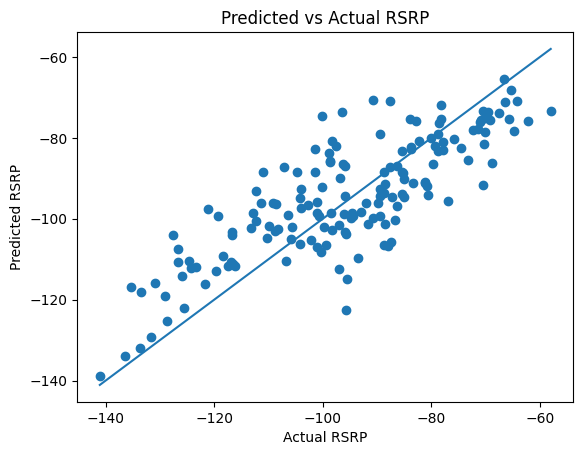

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(actuals, preds)
plt.xlabel("Actual RSRP")
plt.ylabel("Predicted RSRP")
plt.title("Predicted vs Actual RSRP")

# Diagonal reference line
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

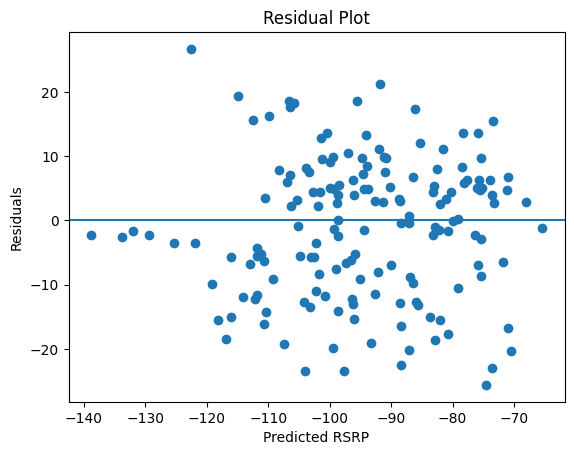

In [ ]:
residuals = actuals - preds

plt.figure()
plt.scatter(preds, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted RSRP")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

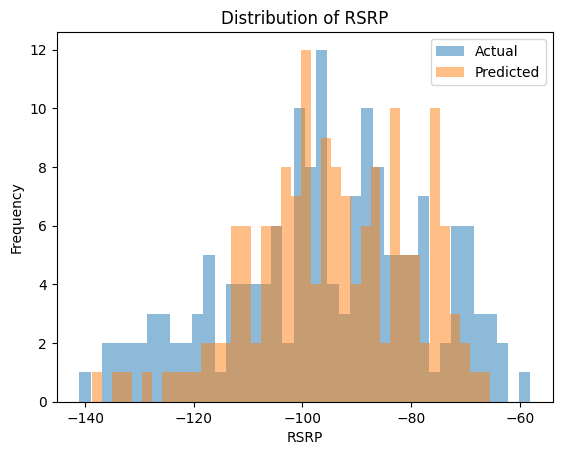

In [ ]:
plt.figure()
plt.hist(actuals, bins=40, alpha=0.5, label="Actual")
plt.hist(preds, bins=40, alpha=0.5, label="Predicted")

plt.xlabel("RSRP")
plt.ylabel("Frequency")
plt.title("Distribution of RSRP")

plt.legend()
plt.show()